In [5]:
import pandas as pd
import numpy as np


In [6]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import mean_squared_error, r2_score,accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [8]:
df.dropna(inplace=True) #Dropping null values

In [9]:
df.shape

(714, 3)

In [10]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


# Without Discretization:

In [11]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [13]:
#extracting x and y
X = df.iloc[:,1:] # since col 0 is our target
Y = df.iloc[:, 0]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [17]:
clf = DecisionTreeClassifier()

In [18]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [19]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [21]:
#Cross validation
np.mean(cross_val_score(DecisionTreeClassifier(),X,Y,cv=5))

0.6274500147739583

# Applying Discretization:

In [25]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [26]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [27]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [28]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42, 14.  , 19.  , 22.  , 25.  , 28.5 , 32.  , 36.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [30]:
trf.named_transformers_['first'].n_bins_

array([10])

In [31]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [33]:
output['age_labels'] = pd.cut(x = X_train['Age'],bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x = X_train['Fare'],bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [35]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
688,18.0,1.0,7.7958,1.0,"(14.0, 19.0]","(7.75, 7.896]"
70,32.0,6.0,10.5000,3.0,"(28.5, 32.0]","(9.225, 13.0]"
0,22.0,3.0,7.2500,0.0,"(19.0, 22.0]","(0.0, 7.75]"
519,32.0,6.0,7.8958,2.0,"(28.5, 32.0]","(7.75, 7.896]"
313,28.0,4.0,7.8958,2.0,"(25.0, 28.5]","(7.75, 7.896]"


In [36]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [37]:
accuracy_score(y_test,y_pred2)

0.6223776223776224

* It is almost same as it is before, change the no of bins lets say from 10 to 15 AND TRY IF IT GETS OPTIMIZED

In [40]:
def discretize(bins, strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=strategy)

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),      # Age column
        ('second', kbin_fare, [1])    # Fare column
    ])

    X_trf = trf.fit_transform(X)

    #  Closing Parenthesis Fixed Here
    print(np.mean(cross_val_score(DecisionTreeClassifier(), X_trf, Y, cv=5)))

    plt.figure(figsize=(14, 10))
    plt.subplot(121)
    plt.hist(X['Age'].dropna(), color='blue', bins=20)   # Drop NaN values
    plt.title("Original Age")

    plt.subplot(122)
    plt.hist(X_trf[:, 0], color='red', bins=20)
    plt.title("Discretized Age")

    plt.show()



0.6624642962671131


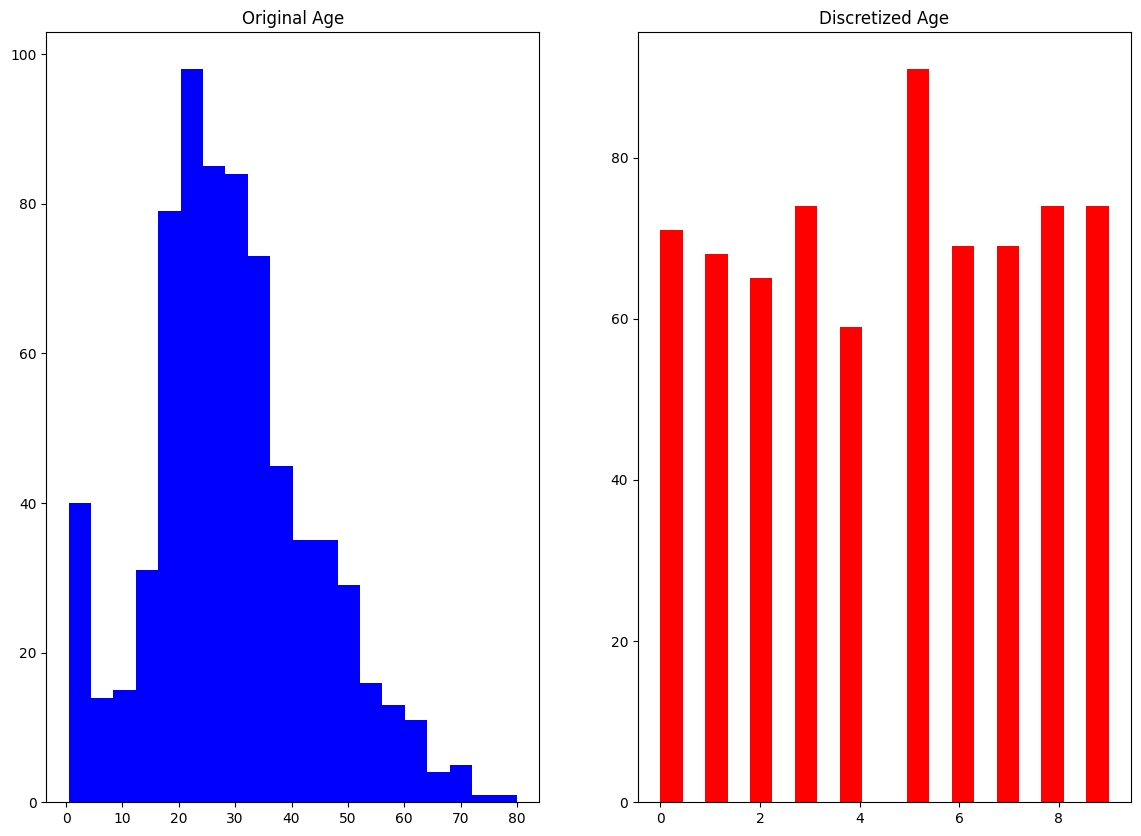

In [41]:
discretize(10,'quantile')